In [11]:
import os
import json
import matplotlib.pyplot as plt
from mable import cli
import numpy as np
import pandas as pd

#Set to current directory (should work on different machines)
os.chdir(os.getcwd())

def profit(metrics_file_name) -> dict:
    incomes = {}
    #print(f"Overview for {metrics_file_name}.")
    with open(metrics_file_name, "r") as f:
        metrics = json.load(f)
    for one_company_key in metrics["company_metrics"]:
        company_name = metrics["company_names"][one_company_key]
        cost = 0
        if "fuel_cost" in metrics["company_metrics"][one_company_key]:
            cost = metrics["company_metrics"][one_company_key]["fuel_cost"]
        penalty = metrics["global_metrics"]["penalty"][one_company_key]
        revenue = 0
        all_outcomes = metrics["global_metrics"]["auction_outcomes"]
        all_outcomes_company_per_round = [d[one_company_key] for d in all_outcomes if one_company_key in d]
        all_outcomes_company = [x for sublist in all_outcomes_company_per_round for x in sublist]
        all_payments = [d["payment"] for d in all_outcomes_company]
        revenue += sum(all_payments)
        income = revenue - cost - penalty
        incomes.update({company_name : income})

    return incomes


def graph():
    files = [f for f in os.listdir() if f.startswith("metrics_competition") and f.endswith(".json")]


    plt.figure()
    labels = []

    for filename in files:
        incomes = profit(filename)
        with open(filename) as f:
            data = json.load(f)
        # print(dict(filename))
        # cli.task_metrics_overview(dict(filename))

        company_names = pd.DataFrame(data['company_names'].items(), columns=['company_index', 'company_name'])
        company_metrics = pd.DataFrame.from_dict(data['company_metrics'], orient='index')
        vessel_metrics = pd.DataFrame.from_dict(data['vessel_metrics'], orient='index')
        auction_outcomes = pd.DataFrame(data['global_metrics']['auction_outcomes']) 

        window_sums = []      # payment per auction window
        total_payment = 0
        fulfilled = 0
        unfulfilled = 0

        for auction in data["global_metrics"]["auction_outcomes"]:
            company_entry = auction.get("0", [])
            
            window_total = 0
            for contract in company_entry:
                p = contract.get("payment", 0)
                window_total += p
                total_payment += p

                if contract.get("fulfilled", False):
                    fulfilled += 1
                else:
                    unfulfilled += 1

            # if company 0 had no trades this window, window_total = 0
            window_sums.append(window_total)

        #print(f"{filename} => payment={total_payment:.2f}, " f"fulfilled={fulfilled}, unfulfilled={unfulfilled}")

        # cumulative over windows
        cumulative = []
        running = 0
        for w in window_sums:
            running += w
            cumulative.append(running)

        plt.plot(cumulative)
        labels.append(filename)

    plt.title("Cumulative Payments per Auction Window (Company 0)")
    plt.xlabel("Auction Window Index")
    plt.ylabel("Cumulative Payment")
    plt.grid(True)
    plt.legend(labels)
    plt.tight_layout()
    plt.show()


'''Get the proportion of profit'''
def profit_proportion():
    pass

'''Get ranking of each company by profit'''
def company_ranking():
    pass

'''Get average profit over n simulations'''
def average_profit():
    pass

'''Get average of profit proportion over n simulations'''
def average_proportion():
    pass

'''Get the cost of company per the number of auctions/trades'''
def cost_per_auction():
    pass


CompanyZ6
Arch Enemy Ltd.
The Scheduler LP
CompanyZ6
Arch Enemy Ltd.
The Scheduler LP


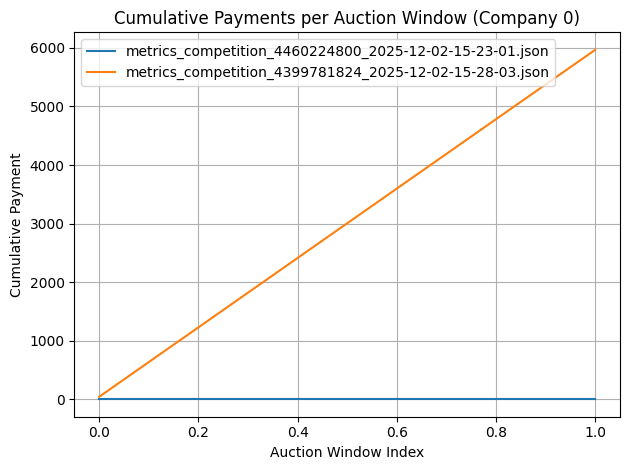

In [3]:
if __name__ == "__main__":
    graph()
    #files = [f for f in os.listdir() if f.startswith("metrics_competition") and f.endswith(".json")]
    #for file in files: pd.read_json(file)
    #pass
  

In [ ]:
files = [f for f in os.listdir() if f.startswith("metrics_competition") and f.endswith(".json")]
company_incomes = {}
for i, filename in enumerate(files):
    incomes = profit(filename)
    with open(filename) as f:
        data = json.load(f)
    # print(dict(filename))
    # cli.task_metrics_overview(dict(filename))
    if i == 0:
        company_names = pd.DataFrame(data['company_names'].items(), columns=['company_index', 'company_name'])
        company_metrics = pd.DataFrame.from_dict(data['company_metrics'], orient='index')
        vessel_metrics = pd.DataFrame.from_dict(data['vessel_metrics'], orient='index')
        auction_outcomes = pd.DataFrame(data['global_metrics']['auction_outcomes']) 



    for key, value in zip(incomes.keys(), incomes.values()): print(f"{key}: {value}")

    for company in incomes.keys():
        
    print("\n\n")
    # else:
    #     company_metrics.concat(data['company_metrics'])
    #     vessel_metrics.concat(data['vessel_metrics'])
    #     auction_outcomes.concat(data['global_metrics']['auction_outcomes']) 

Company3: -47417.60189192648
Company4: -50109.82446054391
Company5: -52499.53514120105
Company6: -50113.41426145996
Company7: -112667.41512582451
Company8: -50025.71921390073
Company9: -49481.319125987946
Company10: -66616.08519684777
Company11: -50386.088977456224
Company12: -50386.088977456224
Company13: -49723.611156399165
Company14: -62003.36039690445
Company15: -48858.73216114668
Company16: -50386.088977456224
Company17: -50386.088977456224
Company18: -49283.60516531818
Company19: -70684.66537328956
Company20: -83131.68806546454
Company1: -52230.16448253864
Company2: -50068.07865403219



Company12: -46417.96130407331
Company13: -49911.01538232957
Company14: -850042.7396785894
Company15: -48816.723069359614
Company16: -50343.63180426351
Company17: -50343.63180426351
Company18: -49029.5399997577
Company19: -66736.96010340369
Company20: -81630.43433757582
Company1: -50911.38349246446
Company2: -50343.63180426351
Company3: -50744.839356634664
Company4: -49728.05520693766
Company5: -1